In [1]:
import numpy as np

# Compatibilidad con NumPy 2.0: np.sctypes fue eliminado
if not hasattr(np, 'sctypes'):
    np.sctypes = {
        'int': [np.int8, np.int16, np.int32, np.int64],
        'uint': [np.uint8, np.uint16, np.uint32, np.uint64],
        'float': [np.float16, np.float32, np.float64],
        'complex': [np.complex64, np.complex128],
        'others': [bool, object, bytes, str, np.void]
    }

import matplotlib.pyplot as plt
import torch
import keras
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Convolution2D, MaxPooling2D, Dropout, Flatten, Dense
import cv2
import pandas as pd
import random
import os
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from imgaug import augmenters as iaa
from matplotlib.patches import Patch

import math
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from keras.layers import Conv2D, Input

# Carga una imagen como arreglo RGB uint8. Usamos cv2 en vez de
# matplotlib.image.imread porque este ultimo devuelve float [0,1] para PNG,
# lo que rompe el /255 del preprocesado y a imgaug (que espera uint8).
def load_image(path):
    return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

In [2]:
OUTPUT_DIR = 'dataset'

In [3]:
if torch.cuda.is_available():
    print(f"GPU detectada : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("ADVERTENCIA: No se detectó GPU — el entrenamiento será muy lento en CPU.")

print(f"Backend Keras : {keras.backend.backend()}")
print(f"PyTorch       : {torch.__version__}")

GPU detectada : NVIDIA GeForce RTX 5080
VRAM          : 17.1 GB
Backend Keras : torch
PyTorch       : 2.12.0+cu130


In [4]:
# El dataset lo genera el controlador de Webots (no se descarga).
# Verificamos que exista antes de continuar.
csv_path = os.path.join(OUTPUT_DIR, 'labels.csv')
images_dir = os.path.join(OUTPUT_DIR, 'images')

if os.path.exists(csv_path):
    n_imgs = len(os.listdir(images_dir)) if os.path.isdir(images_dir) else 0
    print(f"Dataset encontrado: '{csv_path}'")
    print(f"  {n_imgs} imagenes en '{images_dir}/'")
else:
    raise FileNotFoundError(
        f"No se encontro '{csv_path}'. Graba primero el dataset con el "
        f"controlador de Webots (tecla 'g')."
    )

Dataset encontrado: 'dataset/labels.csv'
  27275 imagenes en 'dataset/images/'


In [5]:
# Cargamos el dataset generado por el controlador.
# labels.csv -> columnas: timestamp, sim_time, image, steering, speed
fullDataset = pd.read_csv(csv_path)

print(f"{len(fullDataset):,} registros cargados desde '{csv_path}'")
print(f"Columnas: {list(fullDataset.columns)}")
fullDataset.head()

27,305 registros cargados desde 'dataset/labels.csv'
Columnas: ['timestamp', 'sim_time', 'image', 'steering', 'speed', 'command']


,timestamp,sim_time,image,steering,speed,command
0,JC_20260623_162349_707164,1.600,JC_20260623_162349_707164.png,0.02170,50,2
1,JC_20260623_162350_313201,1.808,JC_20260623_162350_313201.png,-0.01317,50,2
2,JC_20260623_162350_790868,2.016,JC_20260623_162350_790868.png,-0.01054,50,2
3,JC_20260623_162351_368912,2.224,JC_20260623_162351_368912.png,0.01757,50,2
4,JC_20260623_162351_913774,2.432,JC_20260623_162351_913774.png,0.00351,50,2


In [6]:
# La columna 'image' es solo el nombre del archivo
# (ej. 20260620_171827_296211.png). Construimos la ruta completa.
fullDataset['image_path'] = fullDataset['image'].apply(
    lambda f: os.path.join(images_dir, f)
)

print("Ruta de ejemplo:")
print(" ", fullDataset['image_path'].iloc[0])

# Verificamos que las imagenes existen en disco.
n_ok = sum(os.path.exists(p) for p in fullDataset['image_path'])
print(f"\nVerificacion: {n_ok:,} / {len(fullDataset):,} imagenes encontradas.")

Ruta de ejemplo:
  dataset/images/JC_20260623_162349_707164.png

Verificacion: 27,275 / 27,305 imagenes encontradas.


In [7]:
data = fullDataset[['image_path', 'steering']].copy()

# Eliminar filas cuyo archivo no existe en disco
mask_ok = data['image_path'].apply(os.path.exists)
n_missing = (~mask_ok).sum()
if n_missing:
    print(f"Advertencia: {n_missing} imágenes faltantes eliminadas del dataset.")
data = data[mask_ok].reset_index(drop=True)

print(f"Registros: {len(data):,}")
data.head()

Advertencia: 30 imágenes faltantes eliminadas del dataset.
Registros: 27,275


,image_path,steering
0,dataset/images/JC_20260623_162349_707164.png,0.02170
1,dataset/images/JC_20260623_162350_313201.png,-0.01317
2,dataset/images/JC_20260623_162350_790868.png,-0.01054
3,dataset/images/JC_20260623_162351_368912.png,0.01757
4,dataset/images/JC_20260623_162351_913774.png,0.00351


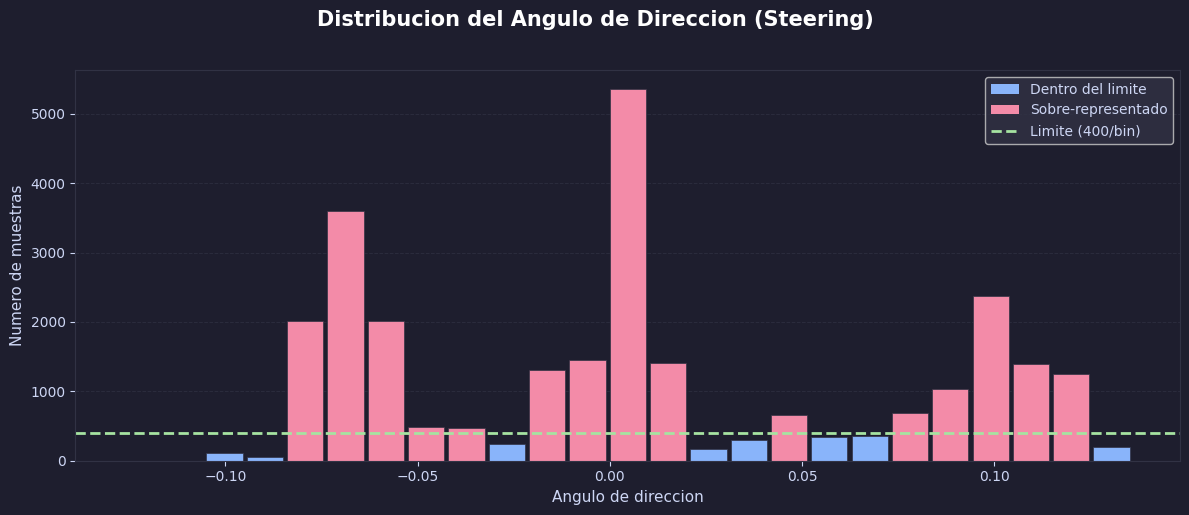

In [8]:
num_bins = 25
samples_per_bin = 400

hist, bins = np.histogram(data['steering'], num_bins)
center = (bins[:-1] + bins[1:]) * 0.5
width = bins[1] - bins[0]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Distribucion del Angulo de Direccion (Steering)', color='white',
             fontsize=15, fontweight='bold', y=1.02)

ax.set_facecolor('#1e1e2e')
colors = ['#f38ba8' if h > samples_per_bin else '#89b4fa' for h in hist]
ax.bar(center, hist, width=width * 0.9, color=colors, edgecolor='#313244', linewidth=0.5)
ax.axhline(samples_per_bin, color='#a6e3a1', linewidth=2, linestyle='--')
ax.set_xlabel('Angulo de direccion', color='#cdd6f4', fontsize=11)
ax.set_ylabel('Numero de muestras', color='#cdd6f4', fontsize=11)
ax.tick_params(colors='#cdd6f4')
for spine in ax.spines.values():
    spine.set_edgecolor('#313244')
ax.grid(axis='y', color='#313244', linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

leyenda = [
    Patch(facecolor='#89b4fa', label='Dentro del limite'),
    Patch(facecolor='#f38ba8', label='Sobre-representado'),
    plt.Line2D([0], [0], color='#a6e3a1', linewidth=2, linestyle='--',
               label=f'Limite ({samples_per_bin}/bin)'),
]
ax.legend(handles=leyenda, facecolor='#313244', labelcolor='#cdd6f4', fontsize=10)

plt.tight_layout()
plt.show()

## Balanceo del Dataset

El histograma anterior muestra que ciertos ángulos de dirección —especialmente `0.0` (ir recto)— están **sobre-representados**. Si el modelo se entrena con datos tan desbalanceados, aprenderá a preferir siempre ir recto y fallará en las curvas.

**Solución — Submuestreo (Undersampling):**
Para cada bin del histograma, si hay más registros que `samples_per_bin`, se eliminan aleatoriamente los sobrantes. Así ningún ángulo domina el entrenamiento y el modelo aprende a generalizar todos los escenarios por igual.

Total antes del balanceo : 27,275
Registros eliminados     : 19,506
Registros restantes      : 7,769


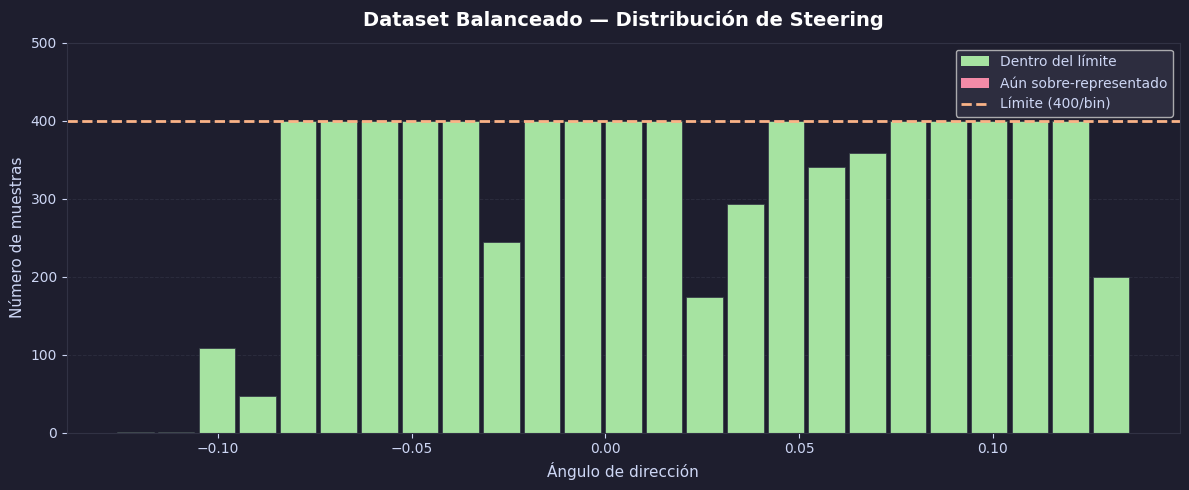

In [9]:
print(f"Total antes del balanceo : {len(data):,}")

remove_list = []
for j in range(num_bins):
    mask = (data['steering'] >= bins[j]) & (data['steering'] <= bins[j + 1])
    bin_indices = data.index[mask].tolist()
    bin_indices = shuffle(bin_indices)
    remove_list.extend(bin_indices[samples_per_bin:])

data.drop(index=remove_list, inplace=True)
data.reset_index(drop=True, inplace=True)

print(f"Registros eliminados     : {len(remove_list):,}")
print(f"Registros restantes      : {len(data):,}")

# --- Histograma post-balanceo ---
hist_bal, _ = np.histogram(data['steering'], num_bins)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

colors_bal = ['#f38ba8' if h > samples_per_bin else '#a6e3a1' for h in hist_bal]
ax.bar(center, hist_bal, width=width * 0.9, color=colors_bal, edgecolor='#313244', linewidth=0.5)
ax.axhline(samples_per_bin, color='#fab387', linewidth=2, linestyle='--')
ax.set_ylim(0, max(hist_bal) * 1.25)

ax.set_title('Dataset Balanceado — Distribución de Steering', color='white', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Ángulo de dirección', color='#cdd6f4', fontsize=11)
ax.set_ylabel('Número de muestras', color='#cdd6f4', fontsize=11)
ax.tick_params(colors='#cdd6f4')
for spine in ax.spines.values():
    spine.set_edgecolor('#313244')
ax.grid(axis='y', color='#313244', linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

leyenda = [
    Patch(facecolor='#a6e3a1', label='Dentro del límite'),
    Patch(facecolor='#f38ba8', label='Aún sobre-representado'),
    plt.Line2D([0], [0], color='#fab387', linewidth=2, linestyle='--', label=f'Límite ({samples_per_bin}/bin)'),
]
ax.legend(handles=leyenda, facecolor='#313244', labelcolor='#cdd6f4', fontsize=10)

plt.tight_layout()
plt.show()

In [10]:
def load_img_steering(df):
    image_paths = []
    steerings = []
    for i in range(len(df)):
        row = df.iloc[i]
        image_paths.append(row['image_path'].strip())
        steerings.append(float(row['steering']))
    return np.asarray(image_paths), np.asarray(steerings)

image_paths, steerings = load_img_steering(data)

print(f"Filas en dataset  : {len(data):,}")
print(f"Imagenes totales  : {len(image_paths):,}")
print(f"Ejemplo de ruta   : {image_paths[0]}")
print(f"Steering min/max  : {steerings.min():.3f} / {steerings.max():.3f}")

Filas en dataset  : 7,769
Imagenes totales  : 7,769
Ejemplo de ruta   : dataset/images/JC_20260623_162349_707164.png
Steering min/max  : -0.126 / 0.136


In [11]:
X_train, X_valid, y_train, y_valid = train_test_split(image_paths, steerings, test_size=0.2, random_state=6)
print('Training Samples: {}\nValid Samples: {}'.format(len(X_train), len(X_valid)))

Training Samples: 6215
Valid Samples: 1554


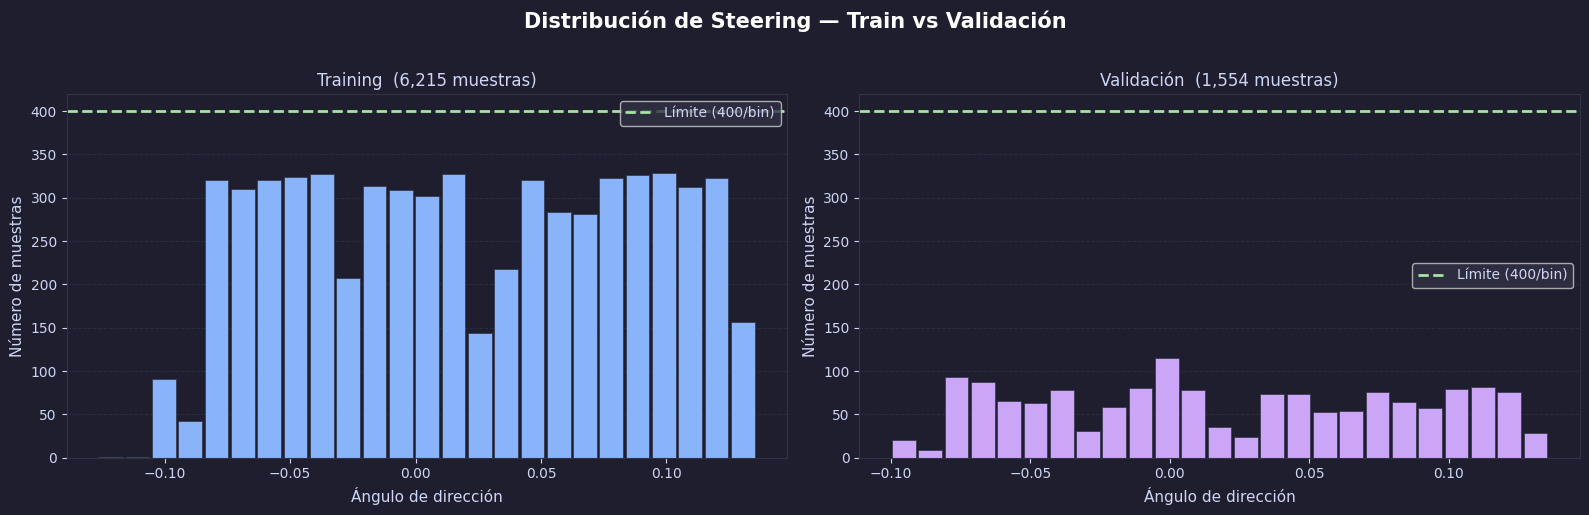

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Distribución de Steering — Train vs Validación', color='white', fontsize=15, fontweight='bold', y=1.02)

datasets = [
    (axes[0], y_train, '#89b4fa', f'Training  ({len(y_train):,} muestras)'),
    (axes[1], y_valid, '#cba6f7', f'Validación  ({len(y_valid):,} muestras)'),
]

for ax, y, color, titulo in datasets:
    hist, bin_edges = np.histogram(y, bins=num_bins)
    centers = (bin_edges[:-1] + bin_edges[1:]) * 0.5
    w = bin_edges[1] - bin_edges[0]
    ax.set_facecolor('#1e1e2e')
    ax.bar(centers, hist, width=w * 0.9, color=color, edgecolor='#313244', linewidth=0.5)
    ax.axhline(samples_per_bin, color='#a6e3a1', linewidth=2, linestyle='--', label=f'Límite ({samples_per_bin}/bin)')
    ax.set_title(titulo, color='#cdd6f4', fontsize=12)
    ax.set_xlabel('Ángulo de dirección', color='#cdd6f4', fontsize=11)
    ax.set_ylabel('Número de muestras', color='#cdd6f4', fontsize=11)
    ax.tick_params(colors='#cdd6f4')
    for spine in ax.spines.values():
        spine.set_edgecolor('#313244')
    ax.grid(axis='y', color='#313244', linestyle='--', linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    ax.legend(facecolor='#313244', labelcolor='#cdd6f4', fontsize=10)

plt.tight_layout()
plt.show()

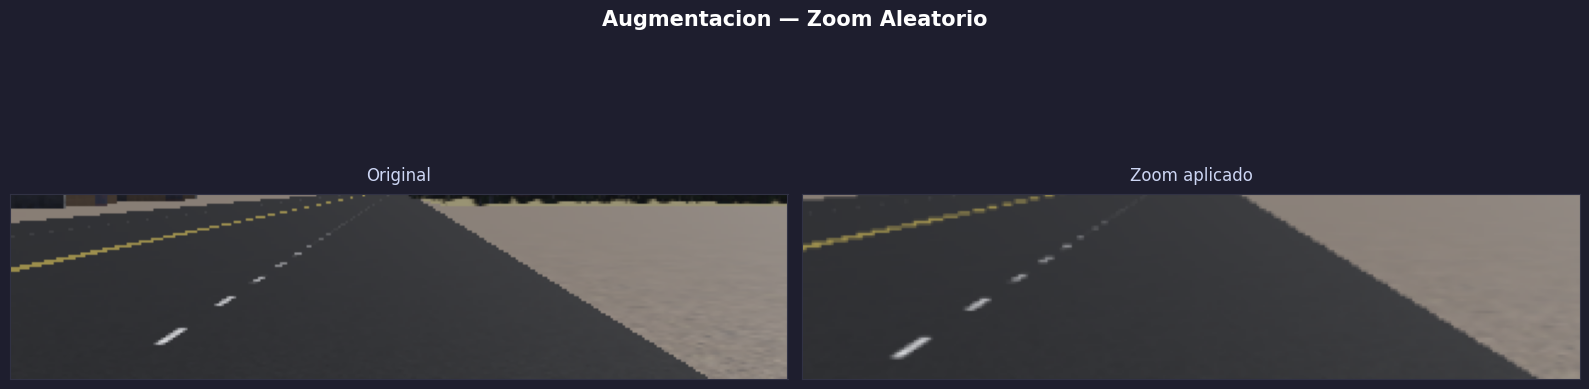

In [13]:
def zoom(image):
    zoom = iaa.Affine(scale=(1, 1.3))
    image = zoom.augment_image(image)
    return image

image = image_paths[random.randint(0, len(image_paths) - 1)]
original_image = load_image(image)
zoomed_image = zoom(original_image)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Augmentacion — Zoom Aleatorio', color='white', fontsize=15, fontweight='bold', y=1.02)

for ax, img, titulo in [
    (axes[0], original_image, 'Original'),
    (axes[1], zoomed_image,   'Zoom aplicado'),
]:
    ax.imshow(img)
    ax.set_title(titulo, color='#cdd6f4', fontsize=12, pad=10)
    ax.set_facecolor('#1e1e2e')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()

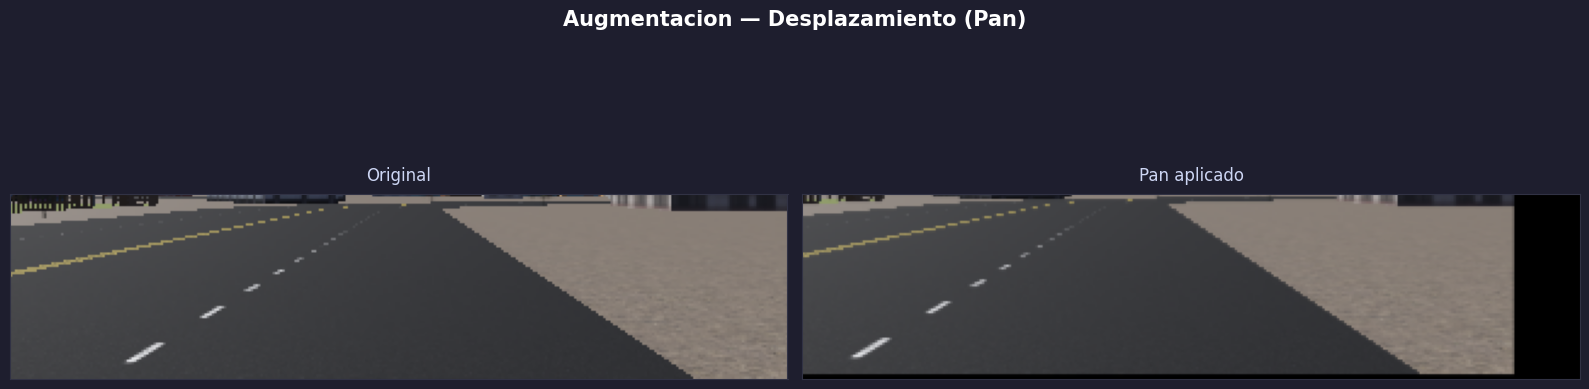

In [14]:
def pan(image):
    pan = iaa.Affine(translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)})
    image = pan.augment_image(image)
    return image

image = image_paths[random.randint(0, len(image_paths) - 1)]
original_image = load_image(image)
panned_image = pan(original_image)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Augmentacion — Desplazamiento (Pan)', color='white', fontsize=15, fontweight='bold', y=1.02)

for ax, img, titulo in [
    (axes[0], original_image, 'Original'),
    (axes[1], panned_image,   'Pan aplicado'),
]:
    ax.imshow(img)
    ax.set_title(titulo, color='#cdd6f4', fontsize=12, pad=10)
    ax.set_facecolor('#1e1e2e')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()

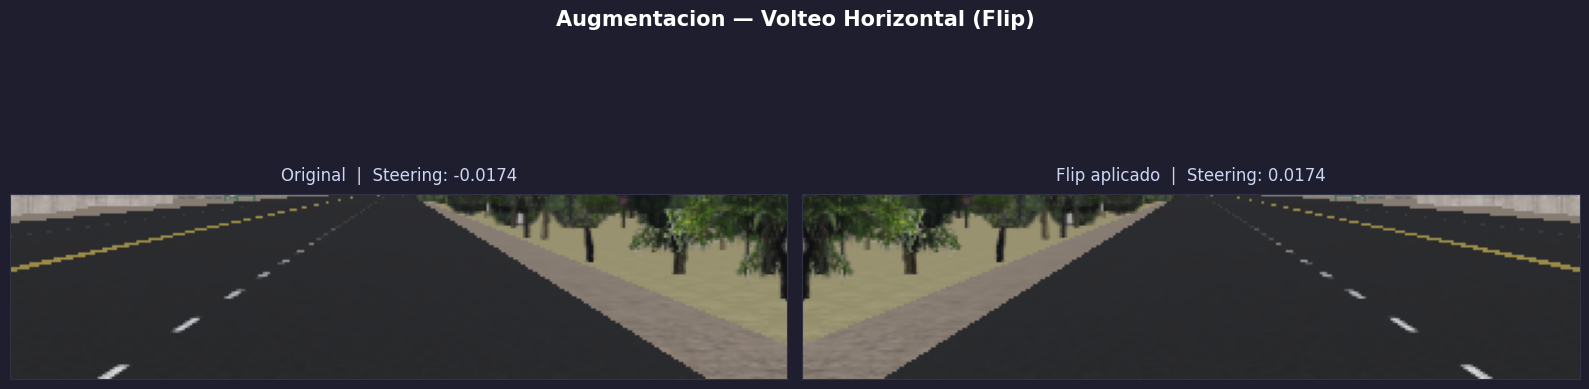

In [15]:
def img_random_flip(image, steering_angle):
    image = cv2.flip(image, 1)
    steering_angle = -steering_angle
    return image, steering_angle

random_index = random.randint(0, len(image_paths) - 1)
original_image = load_image(image_paths[random_index])
steering_angle = steerings[random_index]
flipped_image, flipped_steering = img_random_flip(original_image, steering_angle)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Augmentacion — Volteo Horizontal (Flip)', color='white', fontsize=15, fontweight='bold', y=1.02)

for ax, img, titulo, angle in [
    (axes[0], original_image, 'Original',        steering_angle),
    (axes[1], flipped_image,  'Flip aplicado',   flipped_steering),
]:
    ax.imshow(img)
    ax.set_title(f'{titulo}  |  Steering: {angle:.4f}', color='#cdd6f4', fontsize=12, pad=10)
    ax.set_facecolor('#1e1e2e')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()

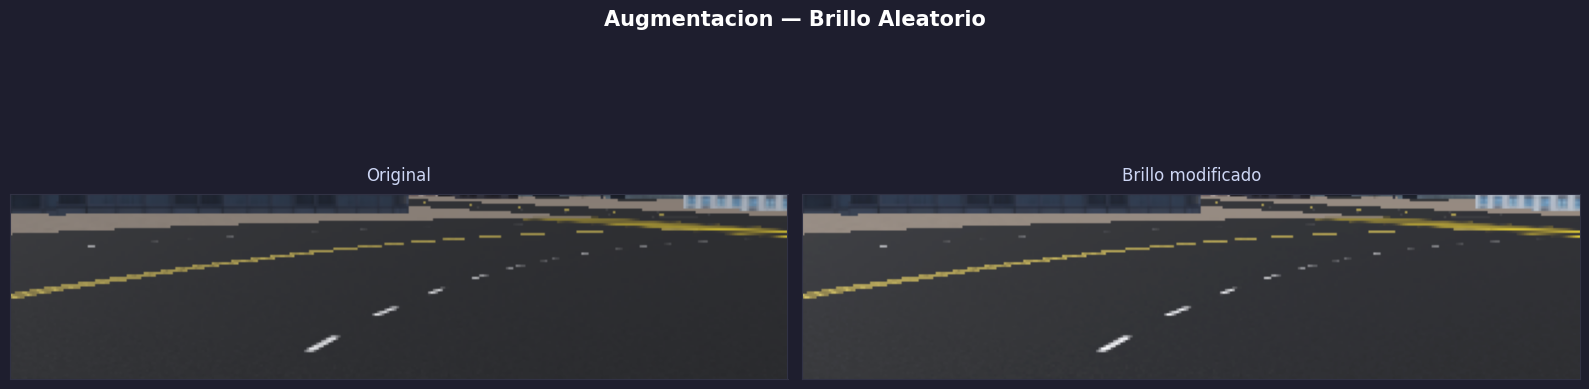

In [16]:
def img_random_brightness(image):
    brightness = iaa.Multiply((0.2, 1.2))
    image = brightness.augment_image(image)
    return image

original_image = load_image(image_paths[random.randint(0, len(image_paths) - 1)])
brightness_altered_image = img_random_brightness(original_image)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Augmentacion — Brillo Aleatorio', color='white', fontsize=15, fontweight='bold', y=1.02)

for ax, img, titulo in [
    (axes[0], original_image,         'Original'),
    (axes[1], brightness_altered_image, 'Brillo modificado'),
]:
    ax.imshow(img)
    ax.set_title(titulo, color='#cdd6f4', fontsize=12, pad=10)
    ax.set_facecolor('#1e1e2e')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()

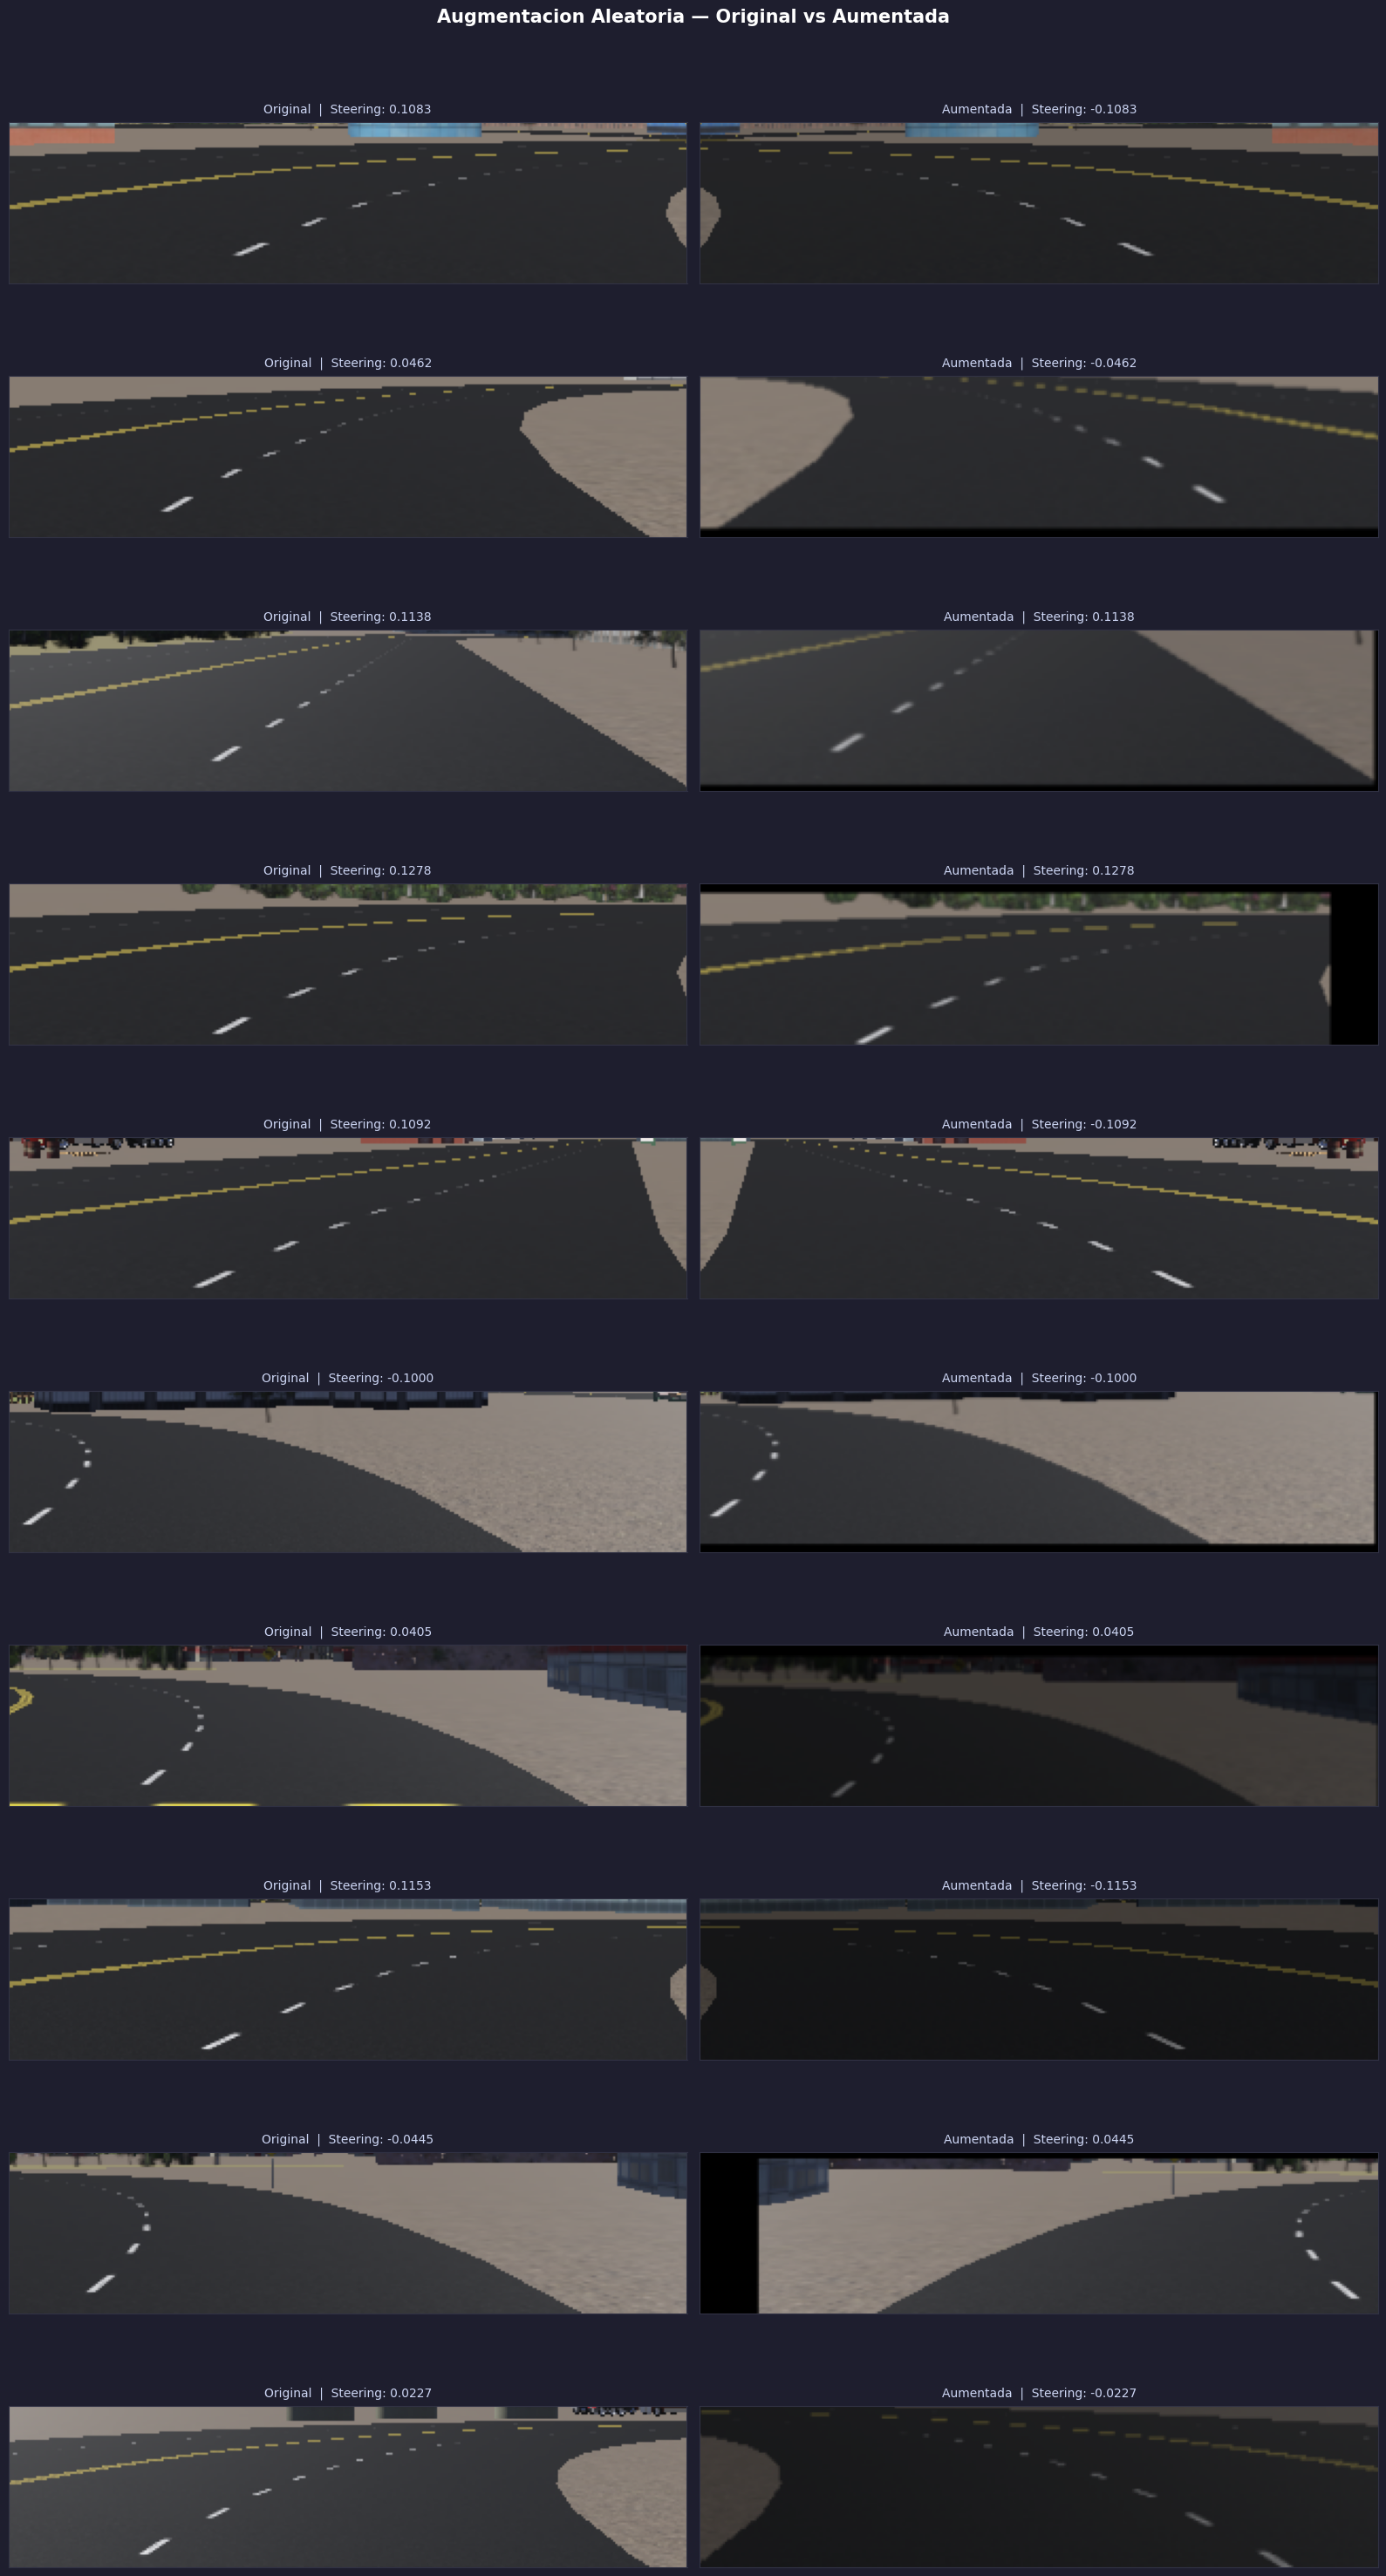

In [17]:
def random_augment(image, steering_angle):
    image = load_image(image)
    if np.random.rand() < 0.5:
        image = pan(image)
    if np.random.rand() < 0.5:
        image = zoom(image)
    if np.random.rand() < 0.5:
        image = img_random_brightness(image)
    if np.random.rand() < 0.5:
        image, steering_angle = img_random_flip(image, steering_angle)
    return image, steering_angle

nrow = 10
fig, axes = plt.subplots(nrow, 2, figsize=(16, nrow * 3))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Augmentacion Aleatoria — Original vs Aumentada', color='white', fontsize=15, fontweight='bold', y=1.005)

for i in range(nrow):
    idx = random.randint(0, len(image_paths) - 1)
    original_image  = load_image(image_paths[idx])
    augmented_image, steering = random_augment(image_paths[idx], steerings[idx])

    for ax, img, titulo in [
        (axes[i][0], original_image,  f'Original  |  Steering: {steerings[idx]:.4f}'),
        (axes[i][1], augmented_image, f'Aumentada  |  Steering: {steering:.4f}'),
    ]:
        ax.imshow(img)
        ax.set_title(titulo, color='#cdd6f4', fontsize=10, pad=8)
        ax.set_facecolor('#1e1e2e')
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()

In [18]:
def img_preprocess(img):
    img = cv2.GaussianBlur(img, (3, 3), 0)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img = img / 127.5 - 1.0
    return img

In [19]:
def batch_generator(image_paths, steering_ang, batch_size, istraining):
    while True:
        batch_img      = []
        batch_steering = []

        for i in range(batch_size):
            random_index = random.randint(0, len(image_paths) - 1)

            if istraining:
                im, steering = random_augment(image_paths[random_index], steering_ang[random_index])
            else:
                im       = load_image(image_paths[random_index])
                steering = steering_ang[random_index]

            batch_img.append(img_preprocess(im))
            batch_steering.append(steering)

        yield np.asarray(batch_img), np.asarray(batch_steering)

print("batch_generator definido correctamente.")
print(f"  Entrenamiento : {len(X_train):,} imagenes")
print(f"  Validacion    : {len(X_valid):,} imagenes")

batch_generator definido correctamente.
  Entrenamiento : 6,215 imagenes
  Validacion    : 1,554 imagenes


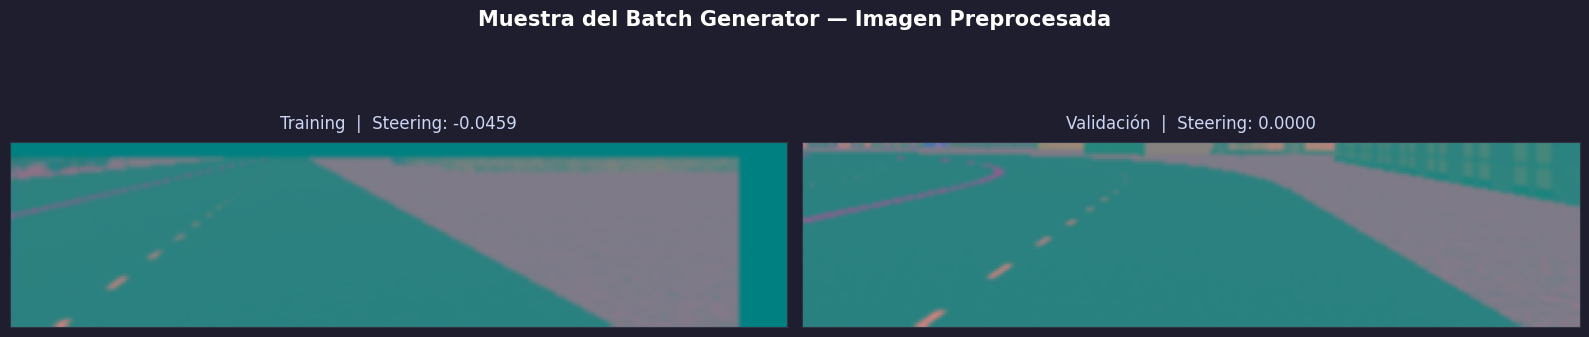

In [20]:
x_train_gen, y_train_gen = next(batch_generator(X_train, y_train, 1, 1))
x_valid_gen, y_valid_gen = next(batch_generator(X_valid, y_valid, 1, 0))

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Muestra del Batch Generator — Imagen Preprocesada', color='white', fontsize=15, fontweight='bold', y=1.02)

for ax, img, steering, titulo in [
    (axes[0], x_train_gen[0], y_train_gen[0], 'Training'),
    (axes[1], x_valid_gen[0], y_valid_gen[0], 'Validación'),
]:
    # Imagen normalizada a [-1,1]: revertimos a [0,1] solo para visualización
    ax.imshow(np.clip((img + 1) / 2, 0, 1))
    ax.set_title(f'{titulo}  |  Steering: {steering:.4f}', color='#cdd6f4', fontsize=12, pad=10)
    ax.set_facecolor('#1e1e2e')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()

In [21]:
def nvidia_model():
    model = Sequential([
        Input(shape=(76, 320, 3)),

        # Bloque convolucional — extracción de características
        Conv2D(24, (5, 5), strides=(2, 2), activation='elu'),
        Conv2D(36, (5, 5), strides=(2, 2), activation='elu'),
        Conv2D(48, (5, 5), strides=(2, 2), activation='elu'),
        Conv2D(64, (3, 3), activation='elu'),
        Conv2D(64, (3, 3), activation='elu'),

        Flatten(),

        # Bloque denso — regresión del ángulo de dirección
        Dense(100, activation='elu'),
        Dropout(0.5),
        Dense(50,  activation='elu'),
        Dropout(0.5),
        Dense(10,  activation='elu'),
        Dense(1),
    ])

    model.compile(optimizer=Adam(learning_rate=1e-4), loss='mse')
    return model

model = nvidia_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 36, 158, 24)    │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 77, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 37, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 35, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 33, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4224)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       422,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 559,419 (2.13 MB)

 Trainable params: 559,419 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
callbacks = [
    ModelCheckpoint(
        'nvidia_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
]

val_steps = math.ceil(len(X_valid) / 100)

history = model.fit(
    batch_generator(X_train, y_train, 100, 1),
    steps_per_epoch  = 300,
    epochs           = 60,
    validation_data  = batch_generator(X_valid, y_valid, 100, 0),
    validation_steps = val_steps,
    callbacks        = callbacks,
    verbose          = 1,
)

Epoch 1/60
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - loss: 0.0094
Epoch 1: val_loss improved from None to 0.00116, saving model to nvidia_model.keras

Epoch 1: finished saving model to nvidia_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 159s 528ms/step - loss: 0.0056 - val_loss: 0.0012 - learning_rate: 1.0000e-04
Epoch 2/60
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - loss: 0.0035
Epoch 2: val_loss did not improve from 0.00116
300/300 ━━━━━━━━━━━━━━━━━━━━ 177s 590ms/step - loss: 0.0033 - val_loss: 0.0013 - learning_rate: 1.0000e-04
Epoch 3/60
299/300 ━━━━━━━━━━━━━━━━━━━━ 0s 716ms/step - loss: 0.0029
Epoch 3: val_loss improved from 0.00116 to 0.00092, saving model to nvidia_model.keras

Epoch 3: finished saving model to nvidia_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 219s 730ms/step - loss: 0.0029 - val_loss: 9.2266e-04 - learning_rate: 1.0000e-04
Epoch 4/60
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - loss: 0.0026
Epoch 4: val_loss improved from 0.00092 to 0.00089, saving model to nvidi

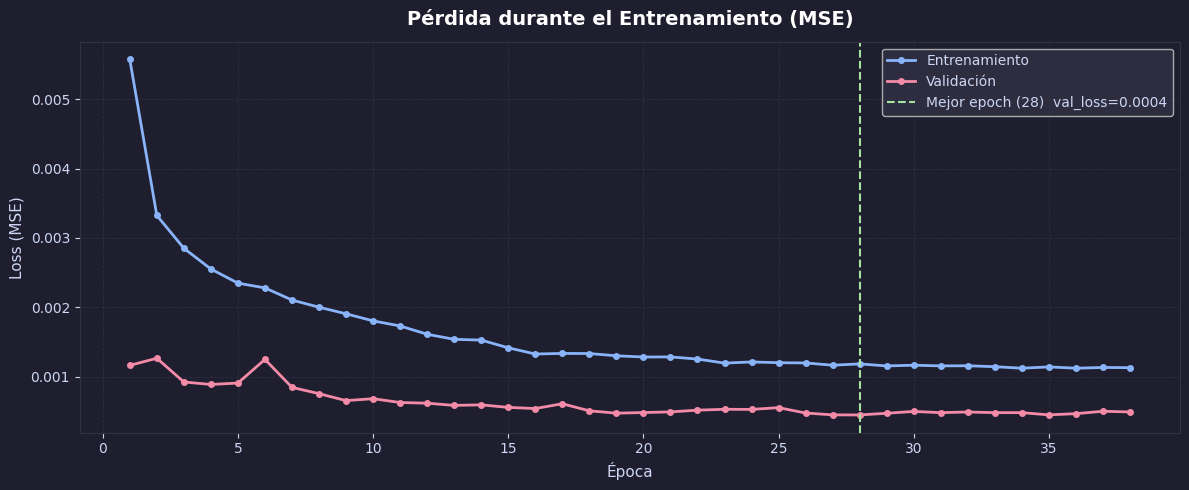

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

epochs = range(1, len(history.history['loss']) + 1)

ax.plot(epochs, history.history['loss'],     color='#89b4fa', linewidth=2, marker='o', markersize=4, label='Entrenamiento')
ax.plot(epochs, history.history['val_loss'], color='#f38ba8', linewidth=2, marker='o', markersize=4, label='Validación')

best_epoch = int(np.argmin(history.history['val_loss'])) + 1
best_val   = min(history.history['val_loss'])
ax.axvline(best_epoch, color='#a6e3a1', linewidth=1.5, linestyle='--', label=f'Mejor epoch ({best_epoch})  val_loss={best_val:.4f}')

ax.set_title('Pérdida durante el Entrenamiento (MSE)', color='white', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Época', color='#cdd6f4', fontsize=11)
ax.set_ylabel('Loss (MSE)', color='#cdd6f4', fontsize=11)
ax.tick_params(colors='#cdd6f4')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
for spine in ax.spines.values():
    spine.set_edgecolor('#313244')
ax.grid(color='#313244', linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)
ax.legend(facecolor='#313244', labelcolor='#cdd6f4', fontsize=10)

plt.tight_layout()
plt.show()

In [24]:
model_path = 'nvidia_model.keras'
model.save(model_path)
print(f"Modelo guardado en '{model_path}'")
print(f"Tamaño : {os.path.getsize(model_path) / 1e6:.2f} MB")

Modelo guardado en 'nvidia_model.keras'
Tamaño : 6.78 MB
